<a href="https://colab.research.google.com/github/poonam-021/explainable-ai-stress-burnout/blob/main/Bio_Physiological_Analysis_of_stress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

============================================================
WESAD Dataset
============================================================

What this script does:
  1. Loads each subject's .pkl file
  2. Extracts EDA, TEMP (chest) and BVP -> HR (wrist)
  3. Synchronizes all signals to 1-second intervals
  4. Filters labels: Baseline (1) vs Stress (2) only
  5. Saves a clean CSV -> wesad_features.csv (ready for Week 2 TabNet)


WESAD Label Reference:
  
  0 = Not defined / transient
  
  1 = Baseline (Relaxed)
  
  2 = Stress  <-- We want this
  
  3 = Amusement
  
  4 = Meditation


Chest RespiBAN sampling rates:
  
  EDA, TEMP, EMG, Resp -> 700 Hz
  
  ECG                  -> 700 Hz
  
  ACC                  -> 700 Hz


Wrist Empatica E4 sampling rates:
  
  BVP  -> 64 Hz
  
  EDA  -> 4 Hz
  
  TEMP -> 4 Hz
  
  ACC  -> 32 Hz
  
  IBI  -> 1 Hz (already events, not fixed rate)

Label sampling rate: 700 Hz (chest device)
============================================================

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks, butter, filtfilt
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "divanshityagi",\r\n  "key": "KGAT_2df1af97b16cc05facf506146cbfb0ef"\r\n}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mohamedasem318/wesad-full-dataset
!unzip -qo wesad-full-dataset.zip -d /content/WESAD

Dataset URL: https://www.kaggle.com/datasets/mohamedasem318/wesad-full-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.42G/2.43G [00:38<00:00, 190MB/s]
100% 2.43G/2.43G [00:38<00:00, 67.5MB/s]


In [ ]:
import os
print(os.listdir("/content/WESAD/WESAD"))

['S11', 'S14', 'S4', 'S17', 'S5', 'S8', 'S15', 'S2', 'wesad_readme.pdf', 'S16', 'S3', 'S6', 'S13', 'S7', 'S9', 'S10']


In [ ]:
print(os.listdir("/content/WESAD/WESAD"))

['S11', 'S14', 'S4', 'S17', 'S5', 'S8', 'S15', 'S2', 'wesad_readme.pdf', 'S16', 'S3', 'S6', 'S13', 'S7', 'S9', 'S10']


In [ ]:
# ─────────────────────────────────────────────
# CONFIGURATION — Edit this path to your data
# ─────────────────────────────────────────────
WESAD_PATH = "/content/WESAD/WESAD"         # Folder containing S2/, S3/, ... subfolders
OUTPUT_CSV = "wesad_features.csv"

# Subjects in the WESAD dataset (S1 was excluded by researchers)
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

# Sampling rates (Hz)
FS_CHEST  = 700   # Chest device (EDA, TEMP, label)
FS_BVP    = 64    # Wrist BVP (used to compute HR)

# Labels we care about
LABEL_BASELINE = 1
LABEL_STRESS   = 2

In [ ]:
# ─────────────────────────────────────────────
# HELPER: Load one subject's .pkl file
# ─────────────────────────────────────────────
def load_subject(subject_id: int) -> dict:
    """Load and return raw data dict for a single subject."""
    pkl_path = os.path.join(WESAD_PATH, f"S{subject_id}", f"S{subject_id}.pkl")
    if not os.path.exists(pkl_path):
        print(f"  [WARNING] File not found: {pkl_path} — skipping.")
        return None
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    return data

In [ ]:
# ─────────────────────────────────────────────
# HELPER: Downsample a signal to 1 Hz (1-sec intervals)
# by taking the mean of every window
# ─────────────────────────────────────────────
def downsample_mean(signal: np.ndarray, fs: int) -> np.ndarray:
    """
    Average every `fs` samples to produce a 1-Hz signal.
    Trims the tail so length is exactly divisible by fs.
    """
    n_seconds = len(signal) // fs
    trimmed    = signal[:n_seconds * fs]
    resampled  = trimmed.reshape(n_seconds, fs).mean(axis=1)
    return resampled

In [ ]:
# ─────────────────────────────────────────────
# HELPER: Bandpass filter for BVP signal
# ─────────────────────────────────────────────
def bandpass_filter(signal: np.ndarray, fs: int,
                    lowcut: float = 0.5, highcut: float = 4.0) -> np.ndarray:
    """Apply a Butterworth bandpass filter (default: 0.5–4 Hz for BVP/HR)."""
    nyq = fs / 2.0
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(3, [low, high], btype="band")
    return filtfilt(b, a, signal)

In [ ]:
# ─────────────────────────────────────────────
# MAIN: Extract features for one subject
# ─────────────────────────────────────────────
def extract_subject_features(subject_id: int) -> pd.DataFrame:
    """
    Load raw data, extract and synchronize EDA, TEMP, HR.
    Returns a DataFrame with columns: [subject, second, EDA, TEMP, HR, label]
    filtered to Baseline (1) and Stress (2) only.
    """
    print(f"\n[Subject S{subject_id}] Loading data...")
    data = load_subject(subject_id)
    if data is None:
        return pd.DataFrame()

    # ── Chest signals (700 Hz) ──────────────────
    chest = data["signal"]["chest"]
    eda_chest  = chest["EDA"].flatten()     # Shape: (N,)
    temp_chest = chest["Temp"].flatten()    # Shape: (N,)
    labels_raw = data["label"].flatten()    # Shape: (N,) at 700 Hz

    # ── Wrist BVP (64 Hz) ───────────────────────
    bvp = data["signal"]["wrist"]["BVP"].flatten()

    print(f"  Chest EDA shape  : {eda_chest.shape}  @ {FS_CHEST} Hz")
    print(f"  Chest TEMP shape : {temp_chest.shape} @ {FS_CHEST} Hz")
    print(f"  Wrist BVP shape  : {bvp.shape}        @ {FS_BVP} Hz")
    print(f"  Labels shape     : {labels_raw.shape}  @ {FS_CHEST} Hz")

    # ── Downsample chest signals to 1 Hz ────────
    print("  Downsampling chest signals to 1 Hz...")
    eda_1hz   = downsample_mean(eda_chest,  FS_CHEST)
    temp_1hz  = downsample_mean(temp_chest, FS_CHEST)
    labels_1hz = downsample_mean(labels_raw, FS_CHEST)
    # Round labels back to integers after averaging
    labels_1hz = np.round(labels_1hz).astype(int)

    # ── Compute HR from BVP at 1 Hz ─────────────
    print("  Computing HR from BVP...")
    hr_1hz = compute_hr_from_bvp(bvp, fs=FS_BVP)

    # ── Align all signals to the shortest length ─
    min_len = min(len(eda_1hz), len(temp_1hz), len(labels_1hz), len(hr_1hz))
    eda_1hz    = eda_1hz[:min_len]
    temp_1hz   = temp_1hz[:min_len]
    labels_1hz = labels_1hz[:min_len]
    hr_1hz     = hr_1hz[:min_len]

    print(f"  Aligned length   : {min_len} seconds (~{min_len/60:.1f} minutes)")

    # ── Build DataFrame ──────────────────────────
    df = pd.DataFrame({
        "subject" : subject_id,
        "second"  : np.arange(min_len),
        "EDA"     : eda_1hz,
        "TEMP"    : temp_1hz,
        "HR"      : hr_1hz,
        "label"   : labels_1hz
    })

    # ── Filter: Keep only Baseline (1) and Stress (2) ──
    df = df[df["label"].isin([LABEL_BASELINE, LABEL_STRESS])].copy()

    # ── Remap labels: Baseline=0, Stress=1 (binary) ──
    df["label"] = df["label"].map({LABEL_BASELINE: 0, LABEL_STRESS: 1})

    baseline_count = (df["label"] == 0).sum()
    stress_count   = (df["label"] == 1).sum()
    print(f"  Baseline seconds : {baseline_count}")
    print(f"  Stress seconds   : {stress_count}")

    return df

In [ ]:
# ─────────────────────────────────────────────
# HELPER: Compute HR (BPM) from BVP in 1-sec windows
# ─────────────────────────────────────────────
def compute_hr_from_bvp(bvp: np.ndarray, fs: int = FS_BVP) -> np.ndarray:
    """
    Derive Heart Rate (BPM) from BVP signal.
    Steps:
      1. Bandpass filter the BVP (0.5–4 Hz covers 30–240 BPM)
      2. Detect peaks (heartbeats)
      3. Compute instantaneous HR per second window
    Returns a 1-Hz HR array in BPM.
    """
    # Filter BVP
    bvp_filtered = bandpass_filter(bvp, fs, lowcut=0.5, highcut=4.0)

    # Detect peaks (R-peaks / pulse peaks)
    # min_distance = 0.4 sec apart (max ~150 BPM)
    min_dist = int(fs * 0.4)
    peaks, _ = find_peaks(bvp_filtered, distance=min_dist)

    n_seconds = len(bvp) // fs
    hr_per_second = np.full(n_seconds, np.nan)

    for sec in range(n_seconds):
        start_sample = sec * fs
        end_sample   = start_sample + fs
        # Peaks that fall in this 1-second window
        peaks_in_window = peaks[(peaks >= start_sample) & (peaks < end_sample)]
        if len(peaks_in_window) >= 1:
            # Use a wider window (±2 sec) around this second to get IBI
            wider_start = max(0, start_sample - fs)
            wider_end   = min(len(bvp), end_sample + fs)
            peaks_wider = peaks[(peaks >= wider_start) & (peaks < wider_end)]
            if len(peaks_wider) >= 2:
                ibis = np.diff(peaks_wider) / fs          # Inter-beat intervals in seconds
                mean_ibi = np.mean(ibis)
                hr_per_second[sec] = 60.0 / mean_ibi      # Convert to BPM

    # Fill NaN gaps with forward/backward fill
    hr_series = pd.Series(hr_per_second).fillna(method="ffill").fillna(method="bfill")
    return hr_series.values

In [ ]:
# ─────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("=" * 60)
    print(f"  Data path : {WESAD_PATH}")
    print(f"  Output    : {OUTPUT_CSV}")
    print(f"  Subjects  : {SUBJECT_IDS}")
    print("=" * 60)

    all_dfs = []

    for sid in SUBJECT_IDS:
        df_subj = extract_subject_features(sid)
        if not df_subj.empty:
            all_dfs.append(df_subj)

    if not all_dfs:
        print("\n[ERROR] No data was loaded. Check your WESAD_PATH.")
    else:
        # Combine all subjects
        combined = pd.concat(all_dfs, ignore_index=True)

        # ── Basic sanity checks ──────────────────
        print("\n" + "=" * 60)
        print("  FINAL DATASET SUMMARY")
        print("=" * 60)
        print(f"  Total samples    : {len(combined)}")
        print(f"  Subjects loaded  : {combined['subject'].nunique()}")
        print(f"  Baseline samples : {(combined['label'] == 0).sum()}")
        print(f"  Stress samples   : {(combined['label'] == 1).sum()}")
        print(f"\n  Feature stats:")
        print(combined[["EDA", "TEMP", "HR"]].describe().round(3).to_string())

        # ── Check for NaN values ─────────────────
        nan_counts = combined[["EDA", "TEMP", "HR"]].isna().sum()
        print(f"\n  NaN counts:")
        print(nan_counts.to_string())
        if nan_counts.sum() > 0:
            print("  [INFO] Dropping rows with NaN values...")
            combined.dropna(subset=["EDA", "TEMP", "HR"], inplace=True)
            print(f"  Remaining samples: {len(combined)}")

        # ── Save to CSV ──────────────────────────
        combined.to_csv(OUTPUT_CSV, index=False)
        print(f"\n  [SUCCESS] Saved to: {OUTPUT_CSV}")
        print("=" * 60)
        print("\n  Columns in output:")
        print("    subject  -> Subject ID (e.g. 2, 3, ...)")
        print("    second   -> Time index within subject session")
        print("    EDA      -> Electrodermal Activity (chest, µS)")
        print("    TEMP     -> Skin Temperature (chest, °C)")
        print("    HR       -> Heart Rate (wrist BVP, BPM)")
        print("    label    -> 0=Baseline, 1=Stress  (binary)")
        print("=" * 60)



  Data path : /content/WESAD/WESAD
  Output    : wesad_features.csv
  Subjects  : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

[Subject S2] Loading data...
  Chest EDA shape  : (4255300,)  @ 700 Hz
  Chest TEMP shape : (4255300,) @ 700 Hz
  Wrist BVP shape  : (389056,)        @ 64 Hz
  Labels shape     : (4255300,)  @ 700 Hz
  Downsampling chest signals to 1 Hz...
  Computing HR from BVP...


/tmp/ipykernel_1638/1839821234.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hr_series = pd.Series(hr_per_second).fillna(method="ffill").fillna(method="bfill")


  Aligned length   : 6079 seconds (~101.3 minutes)
  Baseline seconds : 1147
  Stress seconds   : 619

[Subject S3] Loading data...
  Chest EDA shape  : (4545100,)  @ 700 Hz
  Chest TEMP shape : (4545100,) @ 700 Hz
  Wrist BVP shape  : (415552,)        @ 64 Hz
  Labels shape     : (4545100,)  @ 700 Hz
  Downsampling chest signals to 1 Hz...
  Computing HR from BVP...
  Aligned length   : 6493 seconds (~108.2 minutes)
  Baseline seconds : 1145
  Stress seconds   : 640

[Subject S4] Loading data...
  Chest EDA shape  : (4496100,)  @ 700 Hz
  Chest TEMP shape : (4496100,) @ 700 Hz
  Wrist BVP shape  : (411072,)        @ 64 Hz
  Labels shape     : (4496100,)  @ 700 Hz
  Downsampling chest signals to 1 Hz...
  Computing HR from BVP...
  Aligned length   : 6423 seconds (~107.0 minutes)
  Baseline seconds : 1164
  Stress seconds   : 637

[Subject S5] Loading data...
  Chest EDA shape  : (4380600,)  @ 700 Hz
  Chest TEMP shape : (4380600,) @ 700 Hz
  Wrist BVP shape  : (400512,)        @ 64 Hz

In [ ]:
# ─────────────────────────────────────────────
# SECTION 1: LOAD & FIRST LOOK
# ─────────────────────────────────────────────
df = pd.read_csv("wesad_features.csv")

In [ ]:
print("── Shape ──────────────────────────────────")
print(df.shape)

── Shape ──────────────────────────────────
(27678, 6)


In [ ]:
print("\n── First 5 rows ────────────────────────────")
print(df.head())


── First 5 rows ────────────────────────────
   subject  second       EDA       TEMP          HR  label
0        2     307  5.580099  29.133152   91.976048      0
1        2     308  5.496317  29.138432  111.304348      0
2        2     309  5.414110  29.145496  121.904762      0
3        2     310  5.371765  29.148165   86.292135      0
4        2     311  5.336523  29.148066   79.448276      0


In [ ]:
print("\n── Last 5 rows ─────────────────────────────")
print(df.tail())


── Last 5 rows ─────────────────────────────
       subject  second       EDA       TEMP          HR  label
27673       17    4232  7.348586  34.575077   72.000000      1
27674       17    4233  7.348224  34.576820   96.000000      1
27675       17    4234  7.344271  34.575283  110.503597      1
27676       17    4591  7.491705  34.190273   81.126761      0
27677       17    5653  7.019051  34.075836   69.189189      0


In [ ]:
print("\n── Random 5 rows ───────────────────────────")
print(df.sample(5, random_state=42))


── Random 5 rows ───────────────────────────
       subject  second        EDA       TEMP          HR  label
6676         5    3724  10.939402  34.890068  101.052632      1
12723        9      78   2.144525  33.794765   79.175258      0
3047         3    2384  10.412104  33.732460   85.970149      1
6977         5    4025  10.065134  34.450428   90.000000      1
1122         2    1429   1.098207  30.797573   60.000000      0


In [ ]:
print("\n── Column names & dtypes ───────────────────")
print(df.dtypes)


── Column names & dtypes ───────────────────
subject      int64
second       int64
EDA        float64
TEMP       float64
HR         float64
label        int64
dtype: object


In [ ]:
print("\n── Basic statistics ────────────────────────")
print(df.describe().round(3))


── Basic statistics ────────────────────────
         subject     second        EDA       TEMP         HR      label
count  27678.000  27678.000  27678.000  27678.000  27678.000  27678.000
mean       9.410   1617.406      4.638     33.708     82.580      0.361
std        4.705   1230.787      3.524      1.405     18.014      0.480
min        2.000     26.000      0.469     -2.762     34.909      0.000
25%        5.000    647.000      1.930     33.547     69.398      0.000
50%        9.000   1108.000      3.752     34.041     80.000      0.000
75%       14.000   2537.000      6.452     34.533     94.233      1.000
max       17.000   6505.000     21.952     35.643    151.579      1.000


In [ ]:
# ─────────────────────────────────────────────
# SECTION 2: MISSING VALUES
# ─────────────────────────────────────────────
print("\n── Missing values (count) ──────────────────")
print(df.isnull().sum())

print("\n── Missing values (%) ──────────────────────")
print((df.isnull().sum() / len(df) * 100).round(2))


── Missing values (count) ──────────────────
subject    0
second     0
EDA        0
TEMP       0
HR         0
label      0
dtype: int64

── Missing values (%) ──────────────────────
subject    0.0
second     0.0
EDA        0.0
TEMP       0.0
HR         0.0
label      0.0
dtype: float64


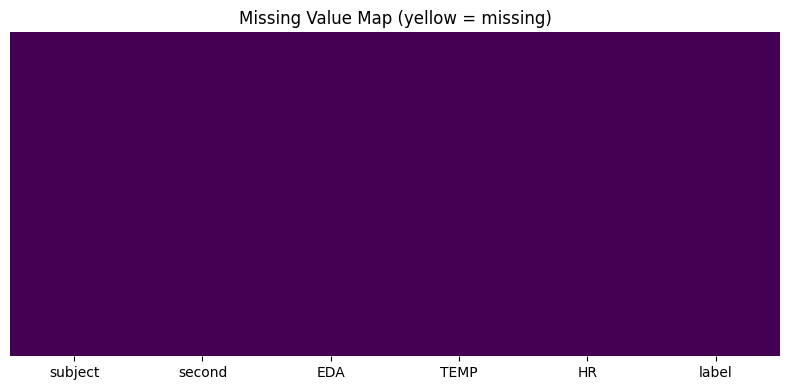

Saved: missing_values.png


In [ ]:
# Visualize missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150)
plt.show()
print("Saved: missing_values.png")

In [ ]:
# Drop rows with any NaN
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f"\nDropped {before - after} NaN rows. Remaining: {after}")


Dropped 0 NaN rows. Remaining: 27678



── Label distribution ──────────────────────
label
0    17679
1     9999
Name: count, dtype: int64

As percentage:
label
0    63.87
1    36.13
Name: proportion, dtype: float64


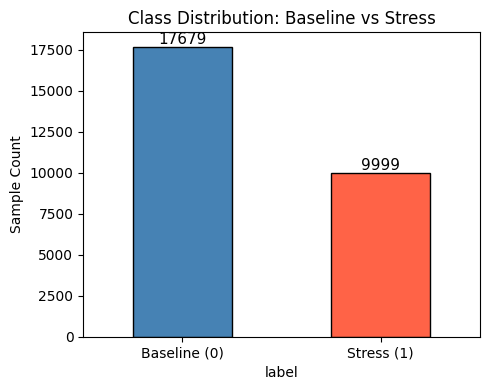

Saved: class_balance.png


In [ ]:
# ─────────────────────────────────────────────
# SECTION 3: CLASS BALANCE
# ─────────────────────────────────────────────
print("\n── Label distribution ──────────────────────")
print(df["label"].value_counts())
print("\nAs percentage:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5, 4))
ax = df["label"].value_counts().plot(kind="bar", color=["steelblue", "tomato"],
                                      edgecolor="black")
ax.set_xticklabels(["Baseline (0)", "Stress (1)"], rotation=0)
ax.set_ylabel("Sample Count")
ax.set_title("Class Distribution: Baseline vs Stress")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig("class_balance.png", dpi=150)
plt.show()
print("Saved: class_balance.png")

In [ ]:
# Per-subject class balance
print("\n── Per-subject label counts ────────────────")
print(df.groupby(["subject", "label"]).size().unstack(fill_value=0))


── Per-subject label counts ────────────────
label       0    1
subject           
2        1147  619
3        1145  640
4        1164  637
5        1203  647
6        1185  653
7        1191  642
8        1172  675
9        1185  647
10       1185  725
11       1183  686
13       1182  664
14       1186  676
15       1180  688
16       1185  675
17       1186  725


In [ ]:
# ─────────────────────────────────────────────
# SECTION 4: OUTLIER DETECTION
# ─────────────────────────────────────────────
features = ["EDA", "TEMP", "HR"]

print("\n── Outlier check (Z-score > 3) ─────────────")
for col in features:
    z_scores = np.abs(stats.zscore(df[col]))
    n_outliers = (z_scores > 3).sum()
    pct = n_outliers / len(df) * 100
    print(f"  {col:5s}: {n_outliers:5d} outliers ({pct:.2f}%)")


── Outlier check (Z-score > 3) ─────────────
  EDA  :   642 outliers (2.32%)
  TEMP :  1024 outliers (3.70%)
  HR   :   123 outliers (0.44%)


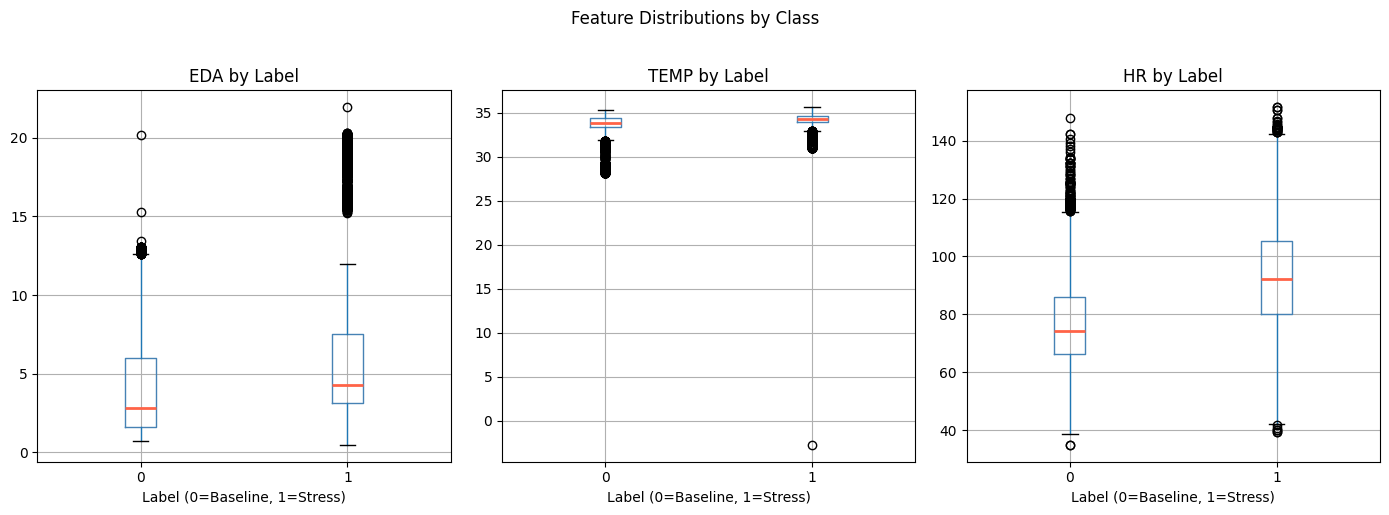

Saved: boxplots.png


In [ ]:
# Boxplots for outlier visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(features):
    df.boxplot(column=col, by="label", ax=axes[i],
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="tomato", linewidth=2))
    axes[i].set_title(f"{col} by Label")
    axes[i].set_xlabel("Label (0=Baseline, 1=Stress)")
plt.suptitle("Feature Distributions by Class", y=1.02)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150)
plt.show()
print("Saved: boxplots.png")

In [ ]:
# Remove outliers using Z-score threshold of 3
print("\n── Removing outliers (|Z| > 3) ─────────────")
before = len(df)
for col in features:
    z_scores = np.abs(stats.zscore(df[col]))
    df = df[z_scores <= 3]
after = len(df)
print(f"Removed {before - after} outlier rows. Remaining: {after}")


── Removing outliers (|Z| > 3) ─────────────
Removed 1789 outlier rows. Remaining: 25889


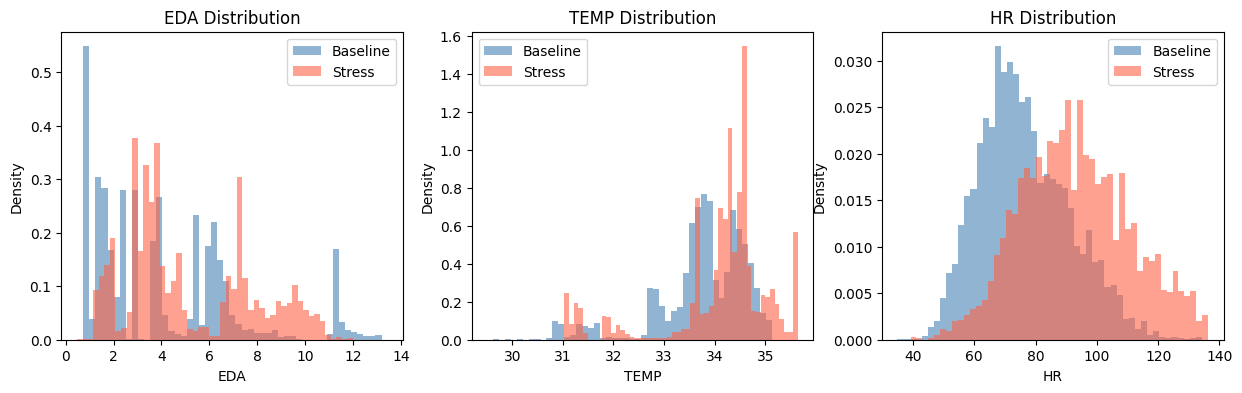

In [ ]:
# ─────────────────────────────────────────────
# SECTION 5: FEATURE DISTRIBUTIONS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {0: "steelblue", 1: "tomato"}
labels_map = {0: "Baseline", 1: "Stress"}

for i, col in enumerate(features):
    for lbl in [0, 1]:
        subset = df[df["label"] == lbl][col]
        axes[i].hist(subset, bins=50, alpha=0.6,
                     color=colors[lbl], label=labels_map[lbl], density=True)
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend()

In [ ]:
plt.suptitle("Feature Distributions: Baseline vs Stress")
plt.tight_layout()
plt.savefig("distributions.png", dpi=150)
plt.show()
print("Saved: distributions.png")

<Figure size 640x480 with 0 Axes>

Saved: distributions.png



── Correlation matrix ──────────────────────
         EDA   TEMP     HR  label
EDA    1.000  0.032 -0.044  0.178
TEMP   0.032  1.000  0.223  0.173
HR    -0.044  0.223  1.000  0.445
label  0.178  0.173  0.445  1.000


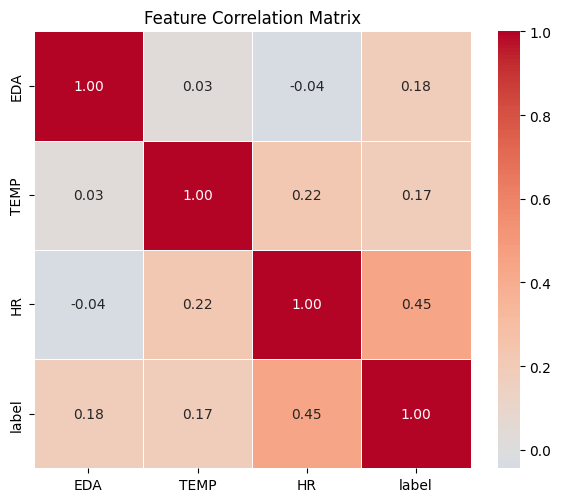

Saved: correlation.png


In [ ]:
# ─────────────────────────────────────────────
# SECTION 6: CORRELATION CHECK
# ─────────────────────────────────────────────
print("\n── Correlation matrix ──────────────────────")
corr = df[features + ["label"]].corr().round(3)
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation.png", dpi=150)
plt.show()
print("Saved: correlation.png")


In [ ]:
# Correlation of each feature with the label
print("\n── Feature correlation with label ──────────")
label_corr = df[features].corrwith(df["label"]).round(3)
print(label_corr.sort_values(ascending=False))


── Feature correlation with label ──────────
HR      0.445
EDA     0.178
TEMP    0.173
dtype: float64


In [ ]:
# ─────────────────────────────────────────────
# SECTION 7: PER-SUBJECT STATS
# ─────────────────────────────────────────────
print("\n── Per-subject feature means ───────────────")
print(df.groupby("subject")[features].mean().round(3))

print("\n── Per-subject sample counts ───────────────")
print(df.groupby("subject").size().rename("total_samples"))



── Per-subject feature means ───────────────
            EDA    TEMP      HR
subject                        
2         1.679  31.394  84.692
3         7.477  31.799  74.629
4         2.275  33.094  72.912
5         6.029  34.701  80.271
6         7.723  33.761  77.585
7        11.503  34.484  75.060
8         3.861  34.907  78.766
9         2.322  34.307  82.109
10        1.189  34.723  96.863
11        6.408  34.436  82.919
13        3.161  33.808  88.748
14        2.863  33.798  87.200
15        2.400  33.936  84.456
16        1.975  33.965  85.707
17        6.123  33.726  80.995

── Per-subject sample counts ───────────────
subject
2      743
3     1781
4     1801
5     1850
6     1838
7     1191
8     1846
9     1832
10    1910
11    1867
13    1846
14    1824
15    1867
16    1796
17    1897
Name: total_samples, dtype: int64


In [ ]:
# ─────────────────────────────────────────────
# SECTION 8: NORMALIZATION (Min-Max Scaling)
# ─────────────────────────────────────────────

print("\n── Normalizing features (per-subject Min-Max) ──")
df_clean = df.copy()

for subj in df_clean["subject"].unique():
    mask = df_clean["subject"] == subj
    for col in features:
        col_min = df_clean.loc[mask, col].min()
        col_max = df_clean.loc[mask, col].max()
        denom = col_max - col_min
        if denom == 0:
            df_clean.loc[mask, col] = 0.0
        else:
            df_clean.loc[mask, col] = (df_clean.loc[mask, col] - col_min) / denom

print("Normalized feature stats (should be in [0, 1]):")
print(df_clean[features].describe().round(3))


── Normalizing features (per-subject Min-Max) ──
Normalized feature stats (should be in [0, 1]):
             EDA       TEMP         HR
count  25889.000  25889.000  25889.000
mean       0.296      0.475      0.429
std        0.313      0.250      0.194
min        0.000      0.000      0.000
25%        0.019      0.282      0.278
50%        0.139      0.455      0.406
75%        0.549      0.649      0.558
max        1.000      1.000      1.000


In [ ]:
# ─────────────────────────────────────────────
# SECTION 9: FINAL CHECKS & SAVE
# ─────────────────────────────────────────────
print("\n── Final dataset info ──────────────────────")
print(f"  Shape       : {df_clean.shape}")
print(f"  Subjects    : {df_clean['subject'].nunique()}")
print(f"  Baseline    : {(df_clean['label'] == 0).sum()}")
print(f"  Stress      : {(df_clean['label'] == 1).sum()}")
print(f"  NaN values  : {df_clean.isnull().sum().sum()}")
print(f"  Duplicates  : {df_clean.duplicated().sum()}")


── Final dataset info ──────────────────────
  Shape       : (25889, 6)
  Subjects    : 15
  Baseline    : 16647
  Stress      : 9242
  NaN values  : 0
  Duplicates  : 0


In [ ]:
# Drop duplicates (just in case)
df_clean.drop_duplicates(inplace=True)

In [ ]:
print("\n── Sample of cleaned data ──────────────────")
print(df_clean.head(10))


── Sample of cleaned data ──────────────────
      subject  second       EDA      TEMP        HR  label
1023        2    1330  0.234436  0.000000  0.571098      0
1024        2    1331  0.234795  0.045738  0.314487      0
1025        2    1332  0.235138  0.089924  0.405904      0
1026        2    1333  0.235095  0.132862  0.491144      0
1027        2    1334  0.234531  0.175186  0.504733      0
1028        2    1335  0.234828  0.215307  0.446494      0
1029        2    1336  0.235902  0.252231  0.452611      0
1030        2    1337  0.235285  0.287911  0.428635      0
1031        2    1338  0.234820  0.321634  0.417120      0
1032        2    1339  0.237420  0.352421  0.363810      0


In [ ]:
# Save cleaned dataset
df_clean.to_csv("wesad_features_clean.csv", index=False)
print("\n[SUCCESS] Saved cleaned dataset -> wesad_features_clean.csv")



[SUCCESS] Saved cleaned dataset -> wesad_features_clean.csv
